In [36]:
from sklearn.calibration import calibration_curve, CalibrationDisplay
import torch
from utils.dataset import Observe
import matplotlib.pyplot as plt
from functools import partial
import numpy as np
from matplotlib.gridspec import GridSpec
from itertools import product

In [37]:
embedding_size = 128
mlp_dim = 64
batch_size = 1024
dir_list = ['raw', 'MC_Dropout', 'Deep_Ensembles', 'Platt_Scaling']

In [38]:


coat_path_list = [f'propensity/{dir}/coat.pt' for dir in dir_list]
yahoo_path_list = [f'propensity/{dir}/yahoo.pt' for dir in dir_list]
kuairand_path_list = [f'propensity/{dir}/kuairand.pt' for dir in dir_list]

sample_ratio = 1
coat_labels = Observe(dataset='coat', train='train', sample_ratio=1, ).click
yahoo_labels = Observe(dataset='yahoo', train='train', sample_ratio=1,).click
kuairand_labels = Observe(dataset='kuairand', train='train', sample_ratio=1,).click


In [39]:
coat_preds_list = [torch.load(path) for path in coat_path_list]
yahoo_preds_list = [torch.load(path) for path in yahoo_path_list]
kuairand_preds_list = [torch.load(path) for path in kuairand_path_list]
eps = np.finfo(float).eps
clip = partial(np.clip, a_min=eps, a_max=1-eps)
# coat_preds_list = map(clip, coat_preds_list)
# yahoo_preds_list = map(clip, yahoo_preds_list)

coat_preds_list = [np.asarray(clip(preds)) for preds in coat_preds_list]
yahoo_preds_list = [np.asarray(clip(preds)) for preds in yahoo_preds_list]
kuairand_preds_list = [np.asarray(clip(preds)) for preds in kuairand_preds_list]



In [40]:
# coat_labels = coat_labels[:len(coat_labels)//2]
# yahoo_labels = yahoo_labels[:len(yahoo_labels)//2]
# coat_preds_list = [preds[:len(preds)//2] for preds in coat_preds_list]
# yahoo_preds_list = [preds[:len(preds)//2] for preds in coat_preds_list]

yahoo_labels = np.asarray(yahoo_labels, np.int32)
coat_labels = np.asarray(coat_labels, np.int32)
kuairand_labels = np.asarray(kuairand_labels, np.int32)


In [41]:
plt.rc('font', size=28)
plt.rc('axes', labelsize=26) #fontsize of the x and y labels
plt.rc('xtick', labelsize=24) #fontsize of the x tick labels
plt.rc('ytick', labelsize=24) #fontsize of the y tick labels
plt.rc('legend', fontsize=26, loc='upper left')
plt.rc ('font',family='Times New Roman')
def draw_multi_calibration_curves(preds_list, labels, data):
    displays = {}
    fig1 = plt.figure(figsize=(12, 12))
    # gs = GridSpec(5, 3)
    ax_calibration_curve = fig1.add_subplot(1,1,1)
    colors = plt.cm.get_cmap("Dark2")

    markes = ['o', 's', '^', 'p',  'v', 'd', 'h', '2', '8', '6']

    for i, (preds, name) in enumerate(zip(preds_list, dir_list)):
        displays[name] = CalibrationDisplay.from_predictions(
            labels, 
            preds, 
            n_bins=20, 
            name=name, 
            ax = ax_calibration_curve, 
            color=colors(i),
            marker=markes[i],
        )

    ax_calibration_curve.grid()
    ax_calibration_curve.set_title('Calibration plots')

    plt.tight_layout()
    plt.savefig(f'results/pic/{data}_curve.pdf', dpi=300, bbox_inches='tight', format='pdf')

    fig2=plt.figure(figsize=(12,12))
    gs=GridSpec(2,2)
    grid_positions = product([0,1], [0,1])
    for i, (preds, name, (row, col)) in enumerate(zip(preds_list, dir_list, grid_positions)):
        ax = fig2.add_subplot(gs[row, col])
        ax.hist(
            displays[name].y_prob,
            range=(0,1),
            bins=20,
            label=name,
            color=colors(i),
        )
        ax.set(title=name,) # xlabel="Mean predicted probability", ylabel="Count")
    plt.tight_layout()
    plt.savefig(f'results/pic/{data}_hist.pdf', dpi=300, bbox_inches='tight', format='pdf')


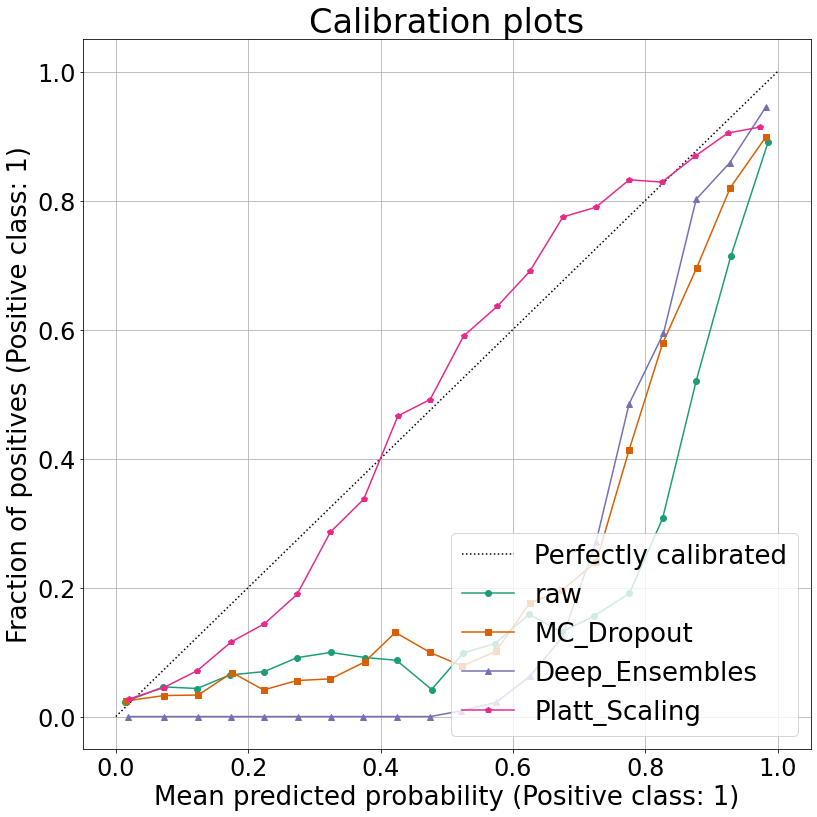

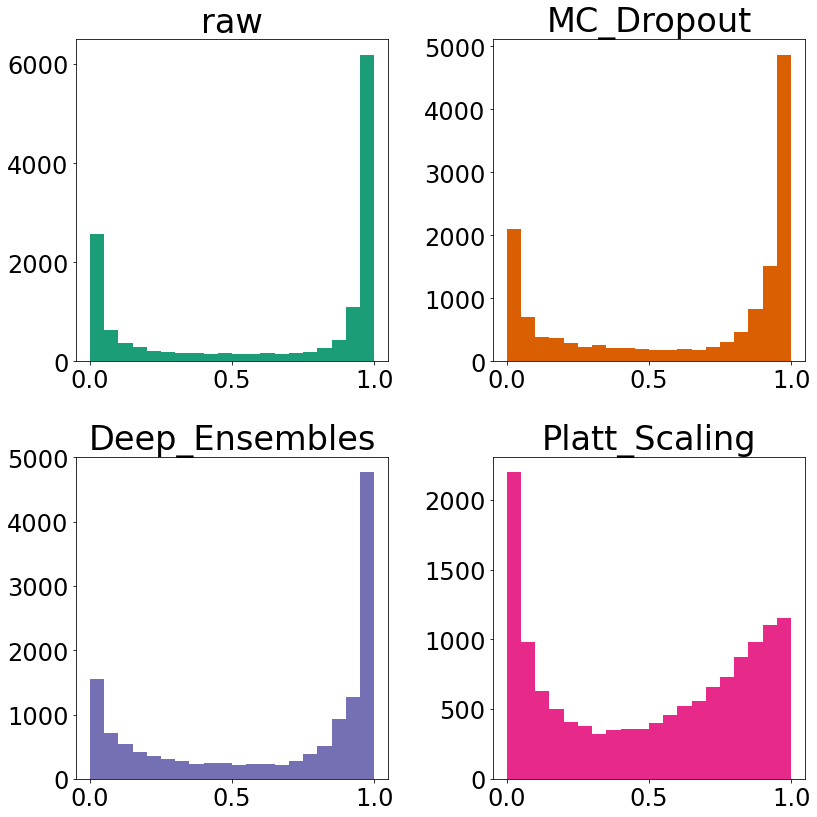

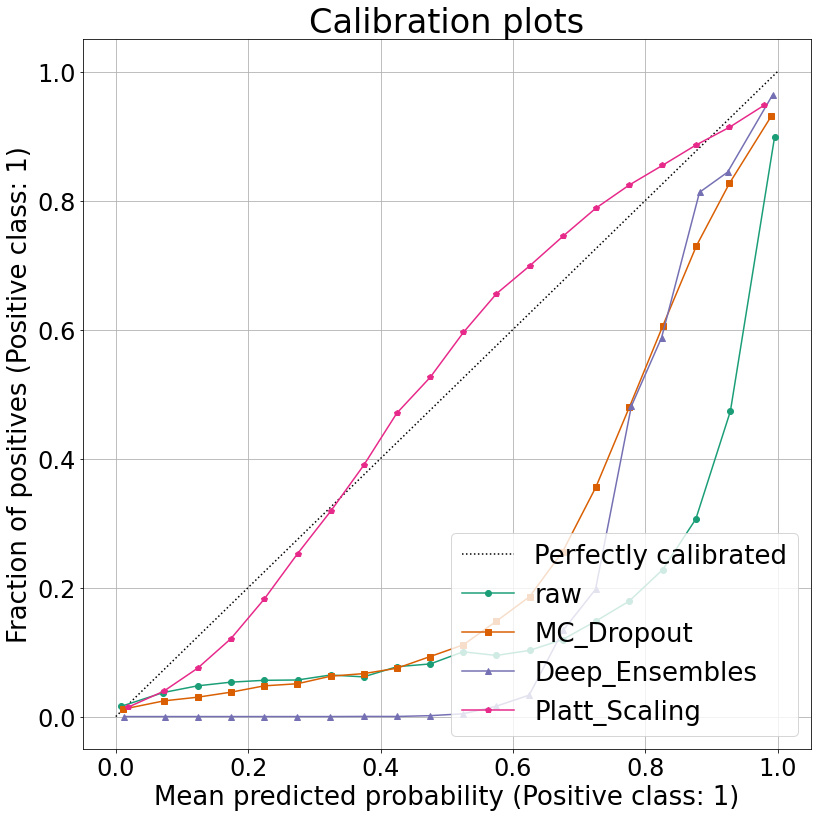

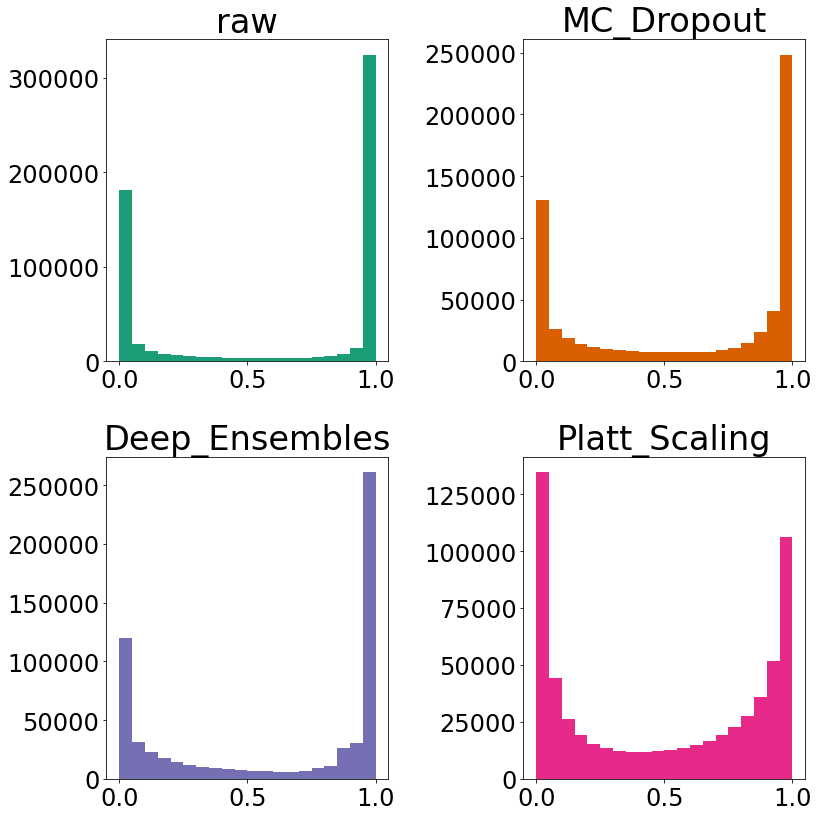

In [43]:
draw_multi_calibration_curves(coat_preds_list, coat_labels, data='coat')
draw_multi_calibration_curves(yahoo_preds_list, yahoo_labels, data='yahoo')
# draw_multi_calibration_curves(kuairand_preds_list, kuairand_labels, data='kuairand')


In [44]:
import matplotlib
print(matplotlib.matplotlib_fname())

/data/sunxin/anaconda3/envs/pytorch/lib/python3.8/site-packages/matplotlib/mpl-data/matplotlibrc


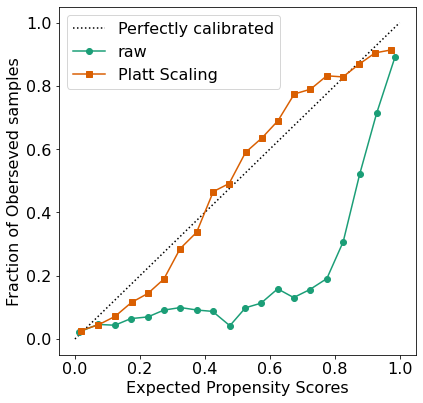

In [48]:
dir_list = ['raw', 'Platt Scaling']
preds_list = [coat_preds_list[0], coat_preds_list[3]]
plt.rc('legend', fontsize=16, loc='upper left')
plt.rc ('font',family='Times New Roman', size=16)
plt.rc('xtick', labelsize=16) #fontsize of the x tick labels
plt.rc('ytick', labelsize=16) #fontsize of the y tick labels
plt.rc('axes', labelsize=16) #fontsize of the x and y labels
data='coat'
displays = {}
fig = plt.figure(figsize=(6.4, 6.4))
ax = fig.add_subplot(1,1,1)
colors = plt.cm.get_cmap("Dark2")
markers = ['o','s']
for i, (preds, name) in enumerate(zip(preds_list, dir_list)):
    displays[name] = CalibrationDisplay.from_predictions(
        coat_labels, 
        preds, 
        n_bins=20, 
        name=name, 
        ax = ax, 
        color=colors(i),
        marker=markers[i],
    )
plt.rc ('font',family='Times New Roman')
plt.legend(loc='upper left')
plt.xlabel('Expected Propensity Scores')
plt.ylabel('Fraction of Oberseved samples')


# ax.grid()
# ax.set_title('Calibration plots')
plt.savefig(f'results/pic/{data}_intro.pdf', bbox_inches='tight', format='pdf')


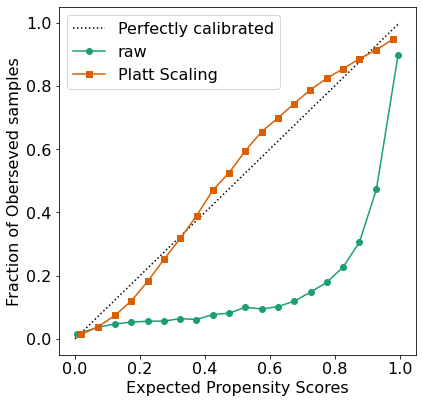

In [46]:
dir_list = ['raw', 'Platt Scaling']
preds_list = [yahoo_preds_list[0], yahoo_preds_list[3]]
plt.rc('legend', fontsize=16, loc='upper left')
plt.rc ('font',family='Times New Roman', size=16)
plt.rc('xtick', labelsize=16) #fontsize of the x tick labels
plt.rc('ytick', labelsize=16) #fontsize of the y tick labels
plt.rc('axes', labelsize=16) #fontsize of the x and y labels
data = 'yahoo'
displays = {}
fig = plt.figure(figsize=(6.4, 6.4))
ax = fig.add_subplot(1,1,1)
colors = plt.cm.get_cmap("Dark2")
markers = ['o','s']
for i, (preds, name) in enumerate(zip(preds_list, dir_list)):
    displays[name] = CalibrationDisplay.from_predictions(
        yahoo_labels, 
        preds, 
        n_bins=20, 
        name=name, 
        ax = ax, 
        color=colors(i),
        marker=markers[i],
    )
plt.rc ('font',family='Times New Roman')
plt.legend(loc='upper left')
plt.xlabel('Expected Propensity Scores')
plt.ylabel('Fraction of Oberseved samples')
# ax.grid()
# ax.set_title('Calibration plots')
plt.savefig(f'results/pic/{data}_intro.pdf', bbox_inches='tight', format='pdf')

ValueError: Found input variables with inconsistent numbers of samples: [2873218, 1436609]

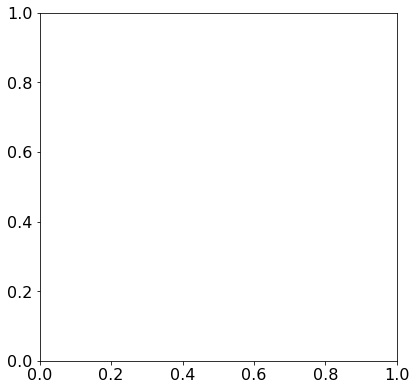

In [47]:
dir_list = ['raw', 'Platt Scaling']
preds_list = [kuairand_preds_list[0], kuairand_preds_list[3]]
plt.rc('legend', fontsize=16, loc='upper left')
plt.rc ('font',family='Times New Roman', size=16)
plt.rc('xtick', labelsize=16) #fontsize of the x tick labels
plt.rc('ytick', labelsize=16) #fontsize of the y tick labels
plt.rc('axes', labelsize=16) #fontsize of the x and y labels
data = 'kuairand'
displays = {}
fig = plt.figure(figsize=(6.4, 6.4))
ax = fig.add_subplot(1,1,1)
colors = plt.cm.get_cmap("Dark2")
markers = ['o','s']
for i, (preds, name) in enumerate(zip(preds_list, dir_list)):
    displays[name] = CalibrationDisplay.from_predictions(
        kuairand_labels, 
        preds, 
        n_bins=20, 
        name=name, 
        ax = ax, 
        color=colors(i),
        marker=markers[i],
    )
plt.rc ('font',family='Times New Roman')
plt.legend(loc='upper left')
plt.xlabel('Expected Propensity Scores')
plt.ylabel('Fraction of Oberseved samples')
# ax.grid()
# ax.set_title('Calibration plots')
plt.savefig(f'results/pic/{data}_intro.pdf', bbox_inches='tight', format='pdf')
